In [2]:
import graphviz
import networkx as nx
from IPython.display import SVG, display

G = graphviz.Digraph(
    "Controlled Pendulum", filename="system_diagram_controlled_pendulum", format="svg"
)

In [3]:
class Component:
    def __init__(self, name):
        self.name = name
        self.inputs = {}
        self.outputs = {}
        self.label = ""

    def add_input(self, input_name):
        self.inputs[input_name] = None

    def add_output(self, output_name):
        self.outputs[output_name] = None

In [4]:
ref = Component("Reference")
ref.add_output("q_ref")
ref.label = "{ Reference | {<out> q_ref} }"

sensor_ref = Component("SensorRef")
sensor_ref.add_input("q_ref")
sensor_ref.add_output("Uq_ref")
sensor_ref.label = "{ {<in> q_ref} | SensorRef | {<out> Uq_ref} }"

sensor_state = Component("SensorState")
sensor_state.add_input("q")
sensor_state.add_output("Uq")
sensor_state.label = "{ {<in> q} | SensorState | {<out> Uq} }"

controller = Component("Controller")
controller.add_input("ref")
controller.add_input("state")
controller.add_output("u")
controller.label = "{ {<in1> ref | <in2> state} | Controller | {<out> u} }"

drive = Component("Drive")
drive.add_input("u")
drive.add_input("omega")
drive.add_output("torque")
drive.label = "{ {<in1> u | <in2> omega} | Drive | {<out> torque} }"

pendulum = Component("Pendulum")
pendulum.add_input("torque")
pendulum.add_output("q")
pendulum.add_output("omega")
pendulum.label = "{ {<in> torque} | Pendulum | {<out1> q | <out2> omega} }"

components = [ref, sensor_ref, sensor_state, controller, drive, pendulum]

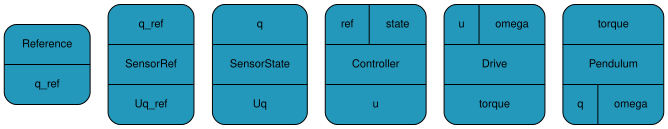

In [5]:
def add_component(dot, component):
    dot.node(
        component.name,
        component.label,
        shape="record",
        fontsize="11",
        style="rounded, filled",
        fillcolor="#2498BB",
        fontname="Helvetica",
        width="1.2",
        height="0.6",
        margin="0.2",
        labelloc="c",
    )


for comp in components:
    add_component(G, comp)

G.render(cleanup=True)  # produces system_diagram.svg

# Show in notebook
display(SVG(filename="system_diagram_controlled_pendulum.svg"))

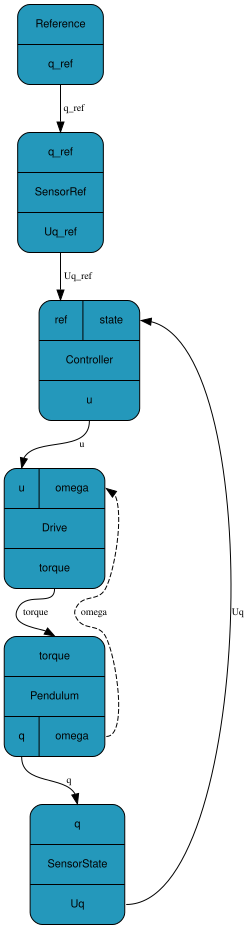

In [6]:
G.edge(
    "Reference",
    "SensorRef",
    tailport="out",
    headport="in",
    label="q_ref",
    style="solid",
    fontsize="10",
)
G.edge(
    "SensorRef",
    "Controller",
    tailport="out",
    headport="in1",
    label="Uq_ref",
    style="solid",
    fontsize="10",
)
G.edge(
    "SensorState",
    "Controller",
    tailport="out",
    headport="in2",
    label="Uq",
    style="solid",
    fontsize="10",
)
G.edge(
    "Controller", "Drive", tailport="out", headport="in1", label="u", style="solid", fontsize="10"
)
G.edge(
    "Drive", "Pendulum", tailport="out", headport="in", label="torque", style="solid", fontsize="10"
)
G.edge(
    "Pendulum",
    "SensorState",
    tailport="out1",
    headport="in",
    label="q",
    style="solid",
    fontsize="10",
)
G.edge(
    "Pendulum",
    "Drive",
    tailport="out2",
    headport="in2",
    label="omega",
    style="dashed",
    fontsize="10",
)


G.render(cleanup=True)  # produces system_diagram.svg

# Show in notebook
display(SVG(filename="system_diagram_controlled_pendulum.svg"))

In [7]:
class Connection:
    def __init__(self, src_comp, src_port, dst_comp, dst_port):
        self.src_comp = src_comp
        self.src_port = src_port
        self.dst_comp = dst_comp
        self.dst_port = dst_port

In [8]:
connections = [
    Connection(ref, "q_ref", sensor_ref, "q_ref"),
    Connection(sensor_ref, "Uq_ref", controller, "ref"),
    Connection(pendulum, "q", sensor_state, "q"),
    Connection(sensor_state, "Uq", controller, "state"),
    Connection(controller, "u", drive, "u"),
    Connection(pendulum, "omega", drive, "omega"),
    Connection(drive, "torque", pendulum, "torque"),
]

In [9]:
# Logical groups to visually cluster related blocks
GROUPS = {
    "Reference": ["Reference Trajectory", "Reference Angle Sensor"],
    "Sensing": ["State Angle Sensor"],
    "Control": ["PID Controller"],
    "Actuation": ["Drive"],
    "Plant": ["Pendulum"],
}

# Edges with optional signal labels
EDGES = [
    ("Reference Trajectory", "Reference Angle Sensor", "ref θ(t)"),
    ("Reference Angle Sensor", "PID Controller", "U_ref"),
    ("Pendulum", "State Angle Sensor", "θ (state)"),
    ("State Angle Sensor", "PID Controller", "U_meas"),
    ("PID Controller", "Drive", "u (control)"),
    ("Drive", "Pendulum", "τ (torque)"),
    ("Pendulum", "Drive", "ω (feedback)"),
]

# Create a directed graph (for data representation and simple checks)
G = nx.DiGraph()
for group, nodes in GROUPS.items():
    for n in nodes:
        G.add_node(n, group=group)

for u, v, label in EDGES:
    G.add_edge(u, v, label=label)

In [10]:
import os
from pathlib import Path

from graphviz import Digraph

In [11]:
# 2) Try rendering with Graphviz
svg_path = Path("my_system_block_diagram.svg")
png_fallback_path = Path("my_system_block_diagram.png")


def render_with_graphviz(G, svg_path):
    dot = Digraph(
        "SystemBlockDiagram",
        filename=str(svg_path.with_suffix(".gv")),
        format="svg",
        graph_attr={
            "rankdir": "LR",
            "splines": "true",
            "pad": "0.1",
            "nodesep": "0.5",
            "ranksep": "0.75",
            "fontsize": "12",
            "fontname": "Helvetica",
            "bgcolor": "white",
            "margin": "0.2",
            "labelloc": "t",
            "label": "System Block Diagram",
        },
        node_attr={
            "shape": "record",
            "style": "rounded,filled",
            "fillcolor": "white",
            "color": "#3b82f6",
            "penwidth": "1.5",
            "fontname": "Helvetica",
            "fontsize": "10",
            "width": "1.5",
            "height": "0.7",
            "margin": "0.1,0.1",
        },
        edge_attr={
            "arrowsize": "0.7",
            "penwidth": "1.2",
            "color": "#111827",
            "fontname": "Helvetica",
            "fontsize": "10",
            "labelfontcolor": "#374151",
            "labelangle": "45",
            "dir": "forward",
            "arrowhead": "open",
            "arrowtail": "none",
            "style": "solid",
        },
    )

    palette = {
        "Reference": "#dbeafe",
        "Sensing": "#dcfce7",
        "Control": "#fee2e2",
        "Actuation": "#fef3c7",
        "Plant": "#e5e7eb",
    }

    for group, nodes in GROUPS.items():
        with dot.subgraph(name=f"cluster_{group}") as c:
            c.attr(
                label=group,
                style="rounded",
                color="#9ca3af",
                bgcolor=palette.get(group, "white"),
                fontname="Helvetica",
                fontsize="12",
            )
            for n in nodes:
                label = "{ {<in1> a | <in2> b} | " + f"{n}" + " | {<o1> x | <o2> y} }"
                c.node(n, label=label)

    for u, v, label in EDGES:
        # feedback edges with dashed lines
        style = "dashed" if (u == "Pendulum" and v == "Drive") else "solid"
        dot.edge(u, v, label=label, style=style, fontsize="10")

    # Render to SVG
    svg = dot.render(cleanup=True)
    # Ensure the output path matches expectations
    if svg_path.exists():
        svg_path.unlink()
    os.replace(svg, svg_path)
    return True, f"Rendered SVG to {svg_path}"


ok, msg = render_with_graphviz(G, svg_path)

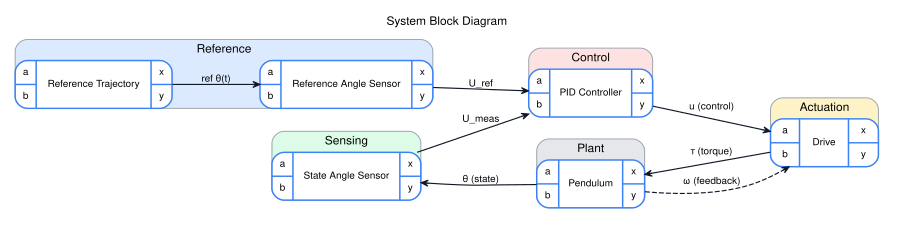

In [12]:
display(SVG(filename=str(svg_path)))